# Incrementalidade financeira de lançamentos

Case **Cientista de Dados Especialista II — Mensuração** (Grupo Boticário).

**Pergunta, em uma frase:** a venda do produto novo é ganho de verdade para a empresa, ou só troca com o que já estava na prateleira?

Este notebook é a análise executiva reproduzível. O relatório metodológico completo está em `docs/Relatório Metodológico_ mensuração da incrementalidade financeira de lançamentos.pdf`. Três seções, nesta ordem:

1. **Metodologia** — o que a base permite, o que recusamos, e como estimamos o ganho.
2. **ROI** — a fórmula proposta, o que esta planilha tem e o que falta.
3. **Aplicação prática e tomada de decisão** — o que o comitê faz com o número.

Este notebook **estima de novo a cada execução**. A chamada é a primeira célula de código, `out = estimar(...)` (`src/incrementality/model.py`). `python scripts/run_pipeline.py` só grava os CSV em `outputs/tables/`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from case_paths import case_root
CASE = case_root()

import importlib
import incrementality.config as _config
import incrementality.model as _model
import incrementality.prepare as _prepare
import incrementality.roi as _roi
importlib.reload(_config)
importlib.reload(_prepare)
importlib.reload(_roi)
importlib.reload(_model)
from incrementality.prepare import carregar, load_raw
from incrementality.model import estimar, pares_usaveis

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAW = load_raw(CASE / "data" / "raw")
produtos, projetos, similares, vendas = carregar(CASE / "data" / "raw")

# Controle sintético + ATT + ROI: src/incrementality/model.py → estimar()
out = estimar(vendas, produtos, projetos)
roi = out["roi"]
att = out["att"]
ev = out["paths_gmv"]
ev_med = out["event_study_medio"]

C = {
    "azul": "#2F5D8A",
    "verde": "#2E7D5B",
    "laranja": "#C45C26",
    "vermelho": "#A33A3A",
    "cinza": "#5F6B7A",
    "claro": "#D9E2EC",
    "sintetico": "#9AA5B1",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "regular",
    "figure.dpi": 110,
    "axes.grid": False,
})

def brl(x, _pos=None):
    ax = abs(x)
    sinal = "-" if x < 0 else ""
    if ax >= 1_000_000:
        return f"{sinal}R$ {ax/1_000_000:.1f} mi"
    if ax >= 1_000:
        return f"{sinal}R$ {ax/1_000:.0f} mil"
    return f"{sinal}R$ {ax:.0f}"

print("case:", CASE)
print({k: v.shape for k, v in RAW.items()})
print("recorte:", out["label"])
print("células mensuráveis (GMV):", int(((att.metric == "gmv") & (att.status == "ok")).sum()), "de", int((att.metric == "gmv").sum()))


case: /Users/igor.lino/Documents/GitHub/case-incrementalidade-lancamentos
{'tb_produtos_atributos': (150, 10), 'tb_projetos_lancamento': (25, 4), 'tb_skus_similares': (285, 3), 'tb_vendas': (519976, 10)}
recorte: marca × subcategoria × faixa_preco
células mensuráveis (GMV): 10 de 24


Três peças distintas, no mesmo exemplo (`SKU_120` / `PROJ_2024_01`):

| Peça | O que é | Neste exemplo |
|---|---|---|
| SKU novo | O lançamento. Não tem pré. | `SKU_120`, Eudora Perfume Masculino P1, nasceu em `202408` |
| Incumbentes da **mesma** célula | Já estavam na prateleira nessa `marca` × `subcategoria` × `faixa_preco`. É a série que observamos. Podem ser canibalizados. **Não** entram no espelho. | `SKU_068` (mesmo P1, desde `202205`) |
| Espelho | Mistura de **outras células** que **nunca** receberam projeto nesta tabela. Os pesos colam o formato da base antiga *antes* do T0. | Óleo corporal, máscara, shampoo, hidratante — não o P1 do próprio `SKU_120` |



In [2]:
# Exemplo real: SKU_120 e a célula Eudora × Perfume Masculino × P1
sku = "SKU_120"
cel = produtos.loc[produtos["cod_sku"] == sku, ["marca_std", "subcategoria", "faixa_preco"]].iloc[0]
mesma = produtos.loc[
    (produtos["marca_std"] == cel["marca_std"])
    & (produtos["subcategoria"] == cel["subcategoria"])
    & (produtos["faixa_preco"] == cel["faixa_preco"]),
    ["cod_sku", "nome_produto", "preco_regular", "cod_ciclo_phase_in", "is_project", "is_incumbent"],
].copy()
mesma["papel"] = np.select(
    [mesma["is_project"], mesma["is_incumbent"]],
    ["Projeto (SKU novo)", "Incumbente da mesma célula"],
    default="Outra inovação",
)
print(f"célula: {cel['marca_std']} × {cel['subcategoria']} × {cel['faixa_preco']}")
display(
    mesma.drop(columns=["is_project", "is_incumbent"])
    .sort_values("cod_ciclo_phase_in")
    .reset_index(drop=True)
)

pesos = att.loc[
    (att["metric"] == "gmv")
    & (att["marca_std"] == cel["marca_std"])
    & (att["subcategoria"] == cel["subcategoria"])
    & (att["faixa_preco"] == cel["faixa_preco"]),
    "pesos",
].iloc[0]
espelho = (
    pd.Series(pesos, name="peso")
    .sort_values(ascending=False)
    .rename_axis("célula doadora")
    .reset_index()
)
espelho[["marca", "subcategoria", "faixa"]] = espelho["célula doadora"].str.split("|", expand=True)
print("espelho (GMV): outras células sem projeto — SKU_068 não está aqui")
display(espelho[["marca", "subcategoria", "faixa", "peso"]])

célula: Eudora × Perfume Masculino × P1


,cod_sku,nome_produto,preco_regular,cod_ciclo_phase_in,papel
0,SKU_068,Eudora Perfume Masculino 68,32.33,202205,Incumbente da mesma célula
1,SKU_120,Eudora Perfume Masculino 120,24.25,202408,Projeto (SKU novo)


espelho (GMV): outras células sem projeto — SKU_068 não está aqui


,marca,subcategoria,faixa,peso
0,O Boticário,Máscara,P4,0.30
1,Eudora,Óleo Corporal,P2,0.28
2,O Boticário,Shampoo,P3,0.18
3,O Boticário,Colônia Infantil,P5,0.13
4,Eudora,Hidratante Corporal,P6,0.11


---

# 1. Metodologia

## 1.1 O que estamos tentando separar

Vender R$ 1 milhão do lançamento **não** significa que o portfólio ganhou R$ 1 milhão. Se o cliente deixou de comprar o shampoo que já existia para comprar o novo, o caixa da empresa quase não mudou — só mudou a etiqueta da caixa.

Os 150 SKUs de `tb_produtos_atributos` caem em três papéis:

| Papel | Regra | Quantos |
|---|---|---|
| **Projeto** | Está em `tb_projetos_lancamento` | 25 |
| **Incumbente** | Já existia antes de 2024 (`cod_ciclo_phase_in` < `202401`) e **não** é um dos 25 | 66 |
| **Outra inovação** | Entrou em 2024 ou depois, mas **não** está na tabela dos 25 | 59 |

**Incumbente** = produto que já estava na prateleira. É a base antiga: o que pode ser canibalizado ou puxado. O SKU novo não tem história antes de nascer; o contrafactual é sobre esses 66, na mesma célula.

O ganho tem duas peças:

1. **Sell-out do SKU novo** — `vlr_venda_praticado` / `margem_bruta` em `tb_vendas`. Observado. Não se modela.
2. **Efeito na base antiga** — o que os incumbentes da mesma célula venderam *a mais ou a menos* do que teriam vendido sem o lançamento.

A peça 2 é o que a literatura chama de **ATT** (*Average Treatment Effect on the Treated*): efeito médio **sobre quem foi tratado**. Aqui o tratado não é o SKU novo (ele não existia). É a **célula** (`marca` × `subcategoria` × `faixa_preco`) que ganhou projeto. O ATT é um único número em R$:

```
efeito na base antiga (ATT) = soma, depois do lançamento, de
    (venda observada dos incumbentes − venda do espelho)
```

No diagnóstico (gráfico, placebo) essa soma vai até o incumbente sair de linha: coluna `att_soma_pos`. No ROI os dois pedaços — sell-out do novo e ATT — usam a **mesma** janela `W` (seção 2.1): coluna `att_soma_roi`.

```
GMV_incremental = Σ vlr_venda_praticado do lançamento em W  +  ATT em W
MB_incremental  = Σ margem_bruta do lançamento em W         +  ATT em W
```

- ATT **negativo** → os incumbentes venderam abaixo do espelho (canibalização).
- ATT **positivo** → venderam acima (a `subcategoria` naquela `faixa_preco` foi puxada).
- ATT **em branco** → não dá para estimar (abre a faixa, ou não há história antes do T0, ou o espelho não colou).

Perfume de R$ 24 não compete com perfume de R$ 314 só porque os dois são “Perfume Masculino Eudora”. `categoria` (Cabelos, Perfumaria, Corpo e Banho) é o nível acima e mistura mercados.


## 1.2 O que a planilha é — e o que precisou de correção

Fonte: `data/Dados_Case_Especialista_II.xlsx`. Geografia: **SP e PR**. Canais: venda direta e loja. Período: ciclo `202401` a `202609` (**43** ciclos comerciais).

Não começamos modelando. Começamos perguntando se os campos conversam uns com os outros.


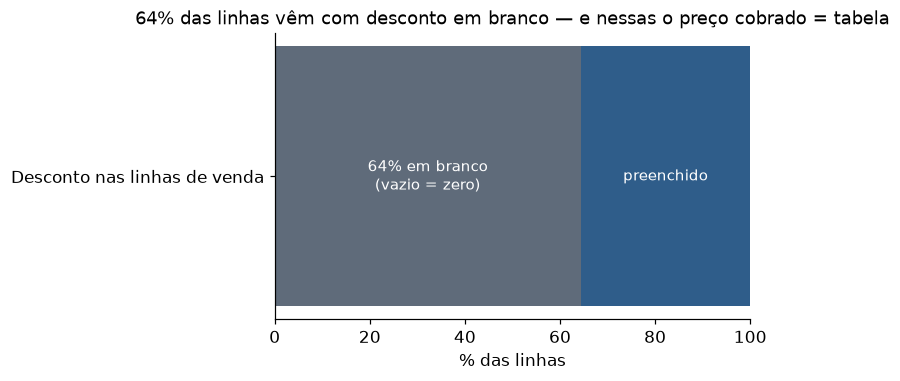

,recorte,linhas,conta_conferida,erro_max
0,desconto em branco,334570,praticado = tabela,0.00
1,desconto > 0,185406,praticado = tabela − desconto,0.00


In [3]:
vnd = RAW["tb_vendas"].copy()
tabela = pd.to_numeric(vnd["vlr_venda_tabela"], errors="coerce")
praticado = pd.to_numeric(vnd["vlr_venda_praticado"], errors="coerce")
desc = pd.to_numeric(vnd["vlr_venda_desconto"], errors="coerce")
nulo = vnd["vlr_venda_desconto"].isna()

resumo_desc = pd.DataFrame({
    "recorte": ["desconto em branco", "desconto > 0"],
    "linhas": [int(nulo.sum()), int((desc > 0).sum())],
    "conta_conferida": ["praticado = tabela", "praticado = tabela − desconto"],
    "erro_max": [
        float((praticado[nulo] - tabela[nulo]).abs().max()),
        float((praticado[desc > 0] - (tabela[desc > 0] - desc[desc > 0])).abs().max()),
    ],
})

fig, ax = plt.subplots(figsize=(7.2, 3.6))
pct_nulo = 100 * nulo.mean()
ax.barh(["Desconto nas linhas de venda"], [pct_nulo], color=C["cinza"], height=0.45)
ax.barh(["Desconto nas linhas de venda"], [100 - pct_nulo], left=[pct_nulo], color=C["azul"], height=0.45)
ax.set_xlim(0, 100)
ax.set_xlabel("% das linhas")
ax.set_title("64% das linhas vêm com desconto em branco — e nessas o preço cobrado = tabela")
ax.text(pct_nulo / 2, 0, f"{pct_nulo:.0f}% em branco\n(vazio = zero)", ha="center", va="center", color="white", fontsize=10)
ax.text(pct_nulo + (100 - pct_nulo) / 2, 0, "preenchido", ha="center", va="center", color="white", fontsize=10)
plt.tight_layout()
plt.show()
resumo_desc


**Por que preenchemos desconto vazio com zero.** Não é convenção. Quando o campo está em branco, o preço cobrado é *exatamente* o de tabela em todas as linhas. Deixar em branco atrapalha soma e média.

Três jeitos de escrever número que o Excel aceita e o programa não: ciclo `2024/01` (2.651 linhas), data de entrada `2022/04` em 3 óleos Eudora, preço `31,34` com vírgula em 3 SKUs. Sem limpar, o programa trata como “faltando” e ~0,5% do GMV saía da série. Depois da limpeza: **zero** ciclo vazio, **43** ciclos distintos, **zero** preço faltando.


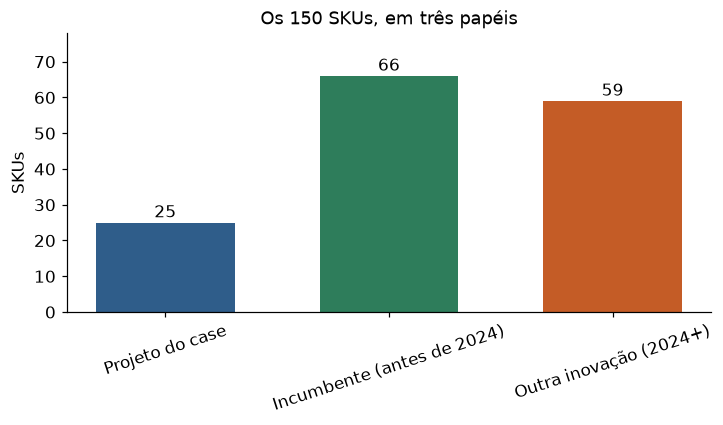

ciclo nulo após mapa: 0 | ciclos distintos: 43
preço NaN: 0 | phase_in NaN: 0


In [4]:
papel = (
    produtos[["is_project", "is_incumbent", "is_other_innovation"]]
    .sum()
)
papel.index = ["Projeto do case", "Incumbente (antes de 2024)", "Outra inovação (2024+)"]

fig, ax = plt.subplots(figsize=(6.8, 4.0))
cores_papel = [C["azul"], C["verde"], C["laranja"]]
ax.bar(papel.index, papel.values, color=cores_papel, width=0.62)
ax.set_ylabel("SKUs")
ax.set_title("Os 150 SKUs, em três papéis")
ax.tick_params(axis="x", rotation=18)
for i, v in enumerate(papel.values):
    ax.text(i, v + 1.5, str(int(v)), ha="center")
ax.set_ylim(0, max(papel.values) * 1.18)
plt.tight_layout()
plt.show()

print("ciclo nulo após mapa:", int(vendas.flag_ciclo_nulo.sum()), "| ciclos distintos:", vendas.cod_ciclo.nunique())
print("preço NaN:", int(produtos.preco_regular.isna().sum()), "| phase_in NaN:", int(produtos.cod_ciclo_phase_in.isna().sum()))


**Por que os três papéis.** O lançamento não tem pré. O contrafactual é sobre os incumbentes. As **59** outras inovações não podem ir para o “resto da categoria”: se forem, o controle está contaminado com lançamento que o case nem listou.

**`tb_skus_similares` não entra no modelo.** `estimar()` recebe só vendas, cadastro e a tabela dos 25 projetos. O efeito na base antiga, o espelho, o placebo e o selo **não** usam a lista de pares.

O que fazemos com ela: uma auditoria, neste ponto da EDA, para documentar por que recusamos o atalho “olha se o similar caiu”. Filtro: mesma `subcategoria`, o par tem de ser incumbente, `score_similaridade_par` ≥ 0,70 (score vazio não é preenchido). Treze dos 25 projetos nem aparecem como principal; a maior parte dos 285 pares cruza `subcategoria`; `SKU_036` (nota 0,97) já estava descontinuado antes de 2024. Os poucos pares que passam no filtro também **não** alimentam o ROI — só mostram que a lista não dá para ser o mapa de canibalização.


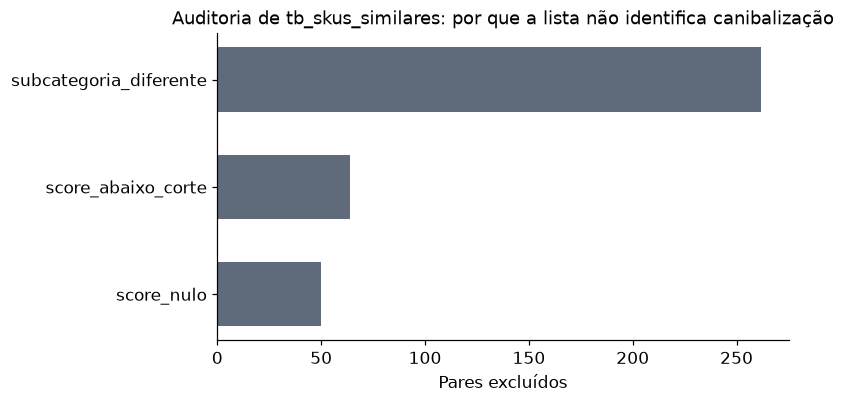

13/25 projetos nem entram como principal. Pares usáveis: 15/285.
Nenhum desses pares entra em estimar(), no efeito da base antiga ou no selo.


,cod_sku_principal,cod_sku_similar,score
89,SKU_046,SKU_066,0.97
207,SKU_108,SKU_106,0.97
95,SKU_049,SKU_066,0.94
221,SKU_119,SKU_107,0.94
33,SKU_020,SKU_121,0.91
178,SKU_094,SKU_011,0.90
121,SKU_064,SKU_028,0.88
49,SKU_026,SKU_008,0.87
50,SKU_026,SKU_065,0.85
60,SKU_030,SKU_044,0.85


In [5]:
sim_flag = pares_usaveis(similares, produtos)
n_sem_lista = (~projetos.cod_sku_lancamento.isin(similares.cod_sku_principal)).sum()
motivos = sim_flag.loc[~sim_flag.usable, "motivo_exclusao"].fillna("").str.split(",").explode().value_counts()

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.barh(motivos.index[::-1], motivos.values[::-1], color=C["cinza"], height=0.6)
ax.set_xlabel("Pares excluídos")
ax.set_title("Auditoria de tb_skus_similares: por que a lista não identifica canibalização")
plt.tight_layout()
plt.show()

print(f"{n_sem_lista}/25 projetos nem entram como principal. Pares usáveis: {int(sim_flag.usable.sum())}/{len(sim_flag)}.")
print("Nenhum desses pares entra em estimar(), no efeito da base antiga ou no selo.")
sim_flag.loc[sim_flag.usable, ["cod_sku_principal", "cod_sku_similar", "score"]].sort_values("score", ascending=False)


## 1.3 Caminhos que recusamos — com motivo nesta planilha

| Caminho comum | Por que não usamos aqui |
|---|---|
| Venda do lançamento vs meta de GMV (`expectativa_gmv_ano1`) | Ignora o que aconteceu com o resto do portfólio. Cada projeto ficou à venda por um tempo diferente (9 a 43 ciclos). Meta é planejamento, não o mundo sem o lançamento. |
| “Os similares caíram depois do lançamento” (`tb_skus_similares`) | Não entra no efeito da base antiga. 13 projetos sem par; pares de outra `subcategoria`; similar já descontinuado; não controla tendência. |
| Ticket com o novo + incumbente da mesma `subcategoria` | Co-ocorrência no cupom não identifica troca. Sem o ticket contrafactual, é retrato e não efeito na base antiga. Não entra no ROI. |
| Comparar SKU novo vs SKU antigo, um a um | Se a base antiga cai, não se sabe *qual* lançamento puxou. Medimos a célula. |
| Marca × subcategoria, **sem** `faixa_preco` | P1 (R$ 24) e P6 (R$ 314) não são o mesmo mercado. O lançamento caro herda o movimento de uma base barata. |
| “O resto da categoria” como contrafactual | 59 produtos novos fora da tabela oficial. O resto não está parado. |

**Por que medimos a célula, não o SKU isolado.** O tratamento começa no primeiro ciclo em que aquela célula ganha um projeto. Nesta base, **23 de 25** projetos ficam sozinhos em `marca` × `subcategoria` × `faixa_preco`. Os dois que ainda dividem espaço (`SKU_008` e `SKU_053`, Perfume Masculino Eudora P3) recebem uma **divisão de conta** proporcional à venda de cada um.


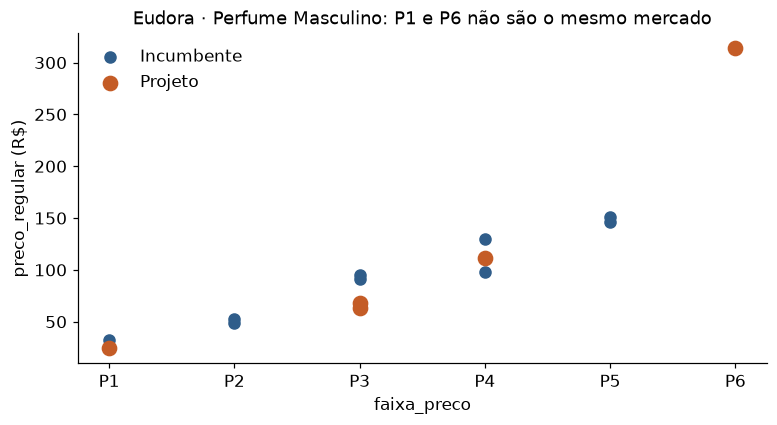

In [6]:
# Por que faixa_preco não é detalhe: P1 e P6 não competem.
rec = produtos.loc[
    (produtos["subcategoria"] == "Perfume Masculino")
    & (produtos["marca_std"] == "Eudora"),
    ["cod_sku", "faixa_preco", "preco_regular", "is_project"],
].dropna()
ordem = [f"P{i}" for i in range(1, 7)]
rec["faixa_preco"] = pd.Categorical(rec["faixa_preco"], categories=ordem, ordered=True)

inc = rec.loc[~rec["is_project"]]
proj = rec.loc[rec["is_project"]]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.scatter(inc["faixa_preco"].cat.codes, inc["preco_regular"], color=C["azul"], s=52, zorder=3, label="Incumbente")
ax.scatter(proj["faixa_preco"].cat.codes, proj["preco_regular"], color=C["laranja"], s=86, zorder=4, label="Projeto")
ax.set_xticks(range(len(ordem)))
ax.set_xticklabels(ordem)
ax.set_xlabel("faixa_preco")
ax.set_ylabel("preco_regular (R$)")
ax.set_title("Eudora · Perfume Masculino: P1 e P6 não são o mesmo mercado")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


## 1.4 Como estimamos “o que teria acontecido”

Não houve experimento (metade das lojas com o produto, metade sem). Temos o histórico.

**Ideia.** Existem células que **nunca** receberam projeto nesta tabela. Elas servem de **espelho**: mesma empresa, mesmo calendário, mesmas UFs, sem aquele choque de inovação.

**Cuidado que aprendemos na prática.** Comparar em reais crus mistura células pequenas com células grandes. O espelho ficava 7 a 16 vezes maior e **inventava** canibalização.

**Como seguimos — controle sintético na trajetória:**

1. Cada curva vira um **índice** (100 = média dela *antes* do lançamento). Comparamos o formato, não o tamanho.
2. O espelho é uma mistura das células sem lançamento. Os pesos são positivos e somam 1. Escolhemos a mistura que melhor acompanha a célula **antes** do T0.
3. Voltamos para reais: índice do espelho × média antiga da célula estudada.
4. Depois do T0, o **ATT** (efeito na base antiga) = soma, ciclo a ciclo, de (`vlr_venda_praticado` dos incumbentes − espelho). Não é o efeito no Brasil nem no SKU novo.

Só publicamos o número se:

1. a célula tinha **pelo menos um** produto antigo;
2. havia **pelo menos 4 ciclos** de histórico antes do primeiro lançamento;
3. o espelho **cola** no pré (RMSPE no máximo 30% da média da série).

O ATT **para** no último ciclo em que ainda há incumbente no cadastro (`cod_ciclo_phase_out`). Preencher zero depois que o SKU saiu de linha e comparar com um espelho ainda vivo **não** é canibalização — é descontinuação. Nesta base isso corta Máscara Boticário P1 (`SKU_014` sai em `202507`, 19 ciclos a menos no pós) e Perfume Masculino Eudora P4 (`SKU_129` sai em `202604`, 5 ciclos a menos). Se algum incumbente da célula segue sem data de saída, a série continua.

**O que é RMSPE.** *Root Mean Squared Prediction Error*: raiz da média dos erros ao quadrado, ciclo a ciclo.

```
RMSPE = √ média( (incumbentes − espelho)² )   no pré
```

É o tamanho típico do erro em R$, com peso maior nos ciclos em que o miss foi grande. Célula de R$ 8 mil/ciclo e célula de R$ 80 mil/ciclo não se comparam nesse R$ cru — por isso dividimos pela média da série no pré. O corte é essa razão.

**Como ler os 30%.** Se a base antiga vendia em média R$ 20 mil por ciclo antes do T0, aceitamos um espelho cujo RMSPE no pré seja até R$ 6 mil por ciclo. É o teste de cola *antes* do choque: se o espelho já divergia demais no pré, o gap do pós não é publicável.

**GMV e margem não compartilham o mesmo espelho.** A lista de doadores é a mesma (células sem projeto). Os pesos são estimados **duas vezes**, em `estimar()`: uma no painel de `vlr_venda_praticado`, outra no de `margem_bruta`. O ATT que entra no ROI de cada métrica é o daquela métrica.

Se falhar, **não estimamos**. Marcamos o motivo. O caso mais comum aqui: o lançamento **abre** a faixa (não havia produto antigo daquele preço).

O código está em `src/incrementality/model.py`.


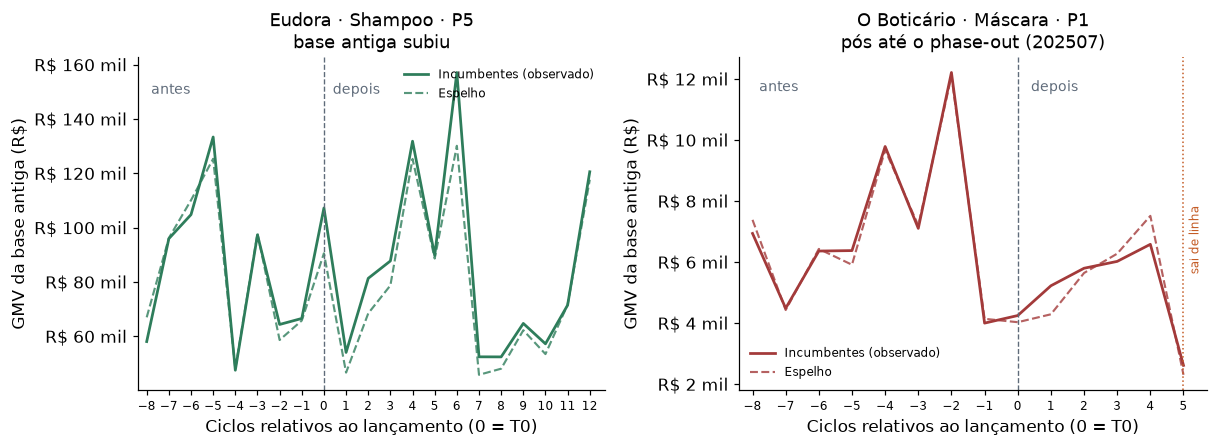

Eudora|Shampoo|P5: ATT GMV = R$ 100,667 · erro pré = 6.56% · 13 ciclos de pós
O Boticário|Máscara|P1: ATT GMV = R$ 432 · erro pré = 6.65% · 6 ciclos de pós · 19 ciclos pós-phase-out fora do ATT


In [7]:
# Dois exemplos em GMV. Máscara: corta no phase_out do incumbente (SKU_014, 202507).
exemplos = [
    ("Eudora|Shampoo|P5", C["verde"], "base antiga subiu"),
    ("O Boticário|Máscara|P1", C["vermelho"], "pós até o phase-out (202507)"),
]
ids = [e[0] for e in exemplos]


def _ate_prateleira(cell_id):
    """Corta a série no último ciclo com incumbente em linha (phase_out)."""
    sub = ev.loc[ev["cell_id"] == cell_id].sort_values("event_time").copy()
    row = att.loc[(att["metric"] == "gmv") & (att["cell_id"] == cell_id)]
    fim, t0 = None, None
    if len(row):
        r = row.iloc[0]
        if "shelf_end_idx" in att.columns and pd.notna(r.get("shelf_end_idx")):
            fim = int(r["shelf_end_idx"])
        if "t0_idx" in att.columns and pd.notna(r.get("t0_idx")):
            t0 = int(r["t0_idx"])
    if fim is None:
        marca, subcat, faixa = cell_id.split("|")
        inc = produtos.loc[
            produtos["is_incumbent"].fillna(False)
            & (produtos["marca_std"] == marca)
            & (produtos["subcategoria"] == subcat)
            & (produtos["faixa_preco"] == faixa)
        ]
        if len(inc) and inc["phase_out_idx"].notna().all():
            fim = int(inc["phase_out_idx"].max())
    if fim is None:
        return sub
    if "ciclo_idx" in sub.columns:
        return sub.loc[sub["ciclo_idx"] <= fim].copy()
    if t0 is not None:
        return sub.loc[sub["event_time"] <= (fim - t0)].copy()
    return sub


fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), sharex=False)
for ax, (cell_id, cor, leitura) in zip(axes, exemplos):
    sub = _ate_prateleira(cell_id)
    ticks = list(range(int(sub["event_time"].min()), int(sub["event_time"].max()) + 1))
    ax.plot(sub["event_time"], sub["observado"], color=cor, lw=1.8, label="Incumbentes (observado)")
    ax.plot(sub["event_time"], sub["sintetico"], color=cor, lw=1.4, ls="--", alpha=0.8, label="Espelho")
    ax.axvline(0, color=C["cinza"], ls="--", lw=0.9)
    ax.set_xticks(ticks)
    ax.set_xlim(float(sub["event_time"].min()) - 0.4, float(sub["event_time"].max()) + 0.7)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("Ciclos relativos ao lançamento (0 = T0)")
    ax.set_ylabel("GMV da base antiga (R$)")
    ax.set_title(f"{cell_id.replace('|', ' · ')}\n{leitura}")
    ax.yaxis.set_major_formatter(FuncFormatter(brl))
    ax.legend(frameon=False, fontsize=8)
    y_top = float(max(sub["observado"].max(), sub["sintetico"].max()))
    ax.text(float(sub["event_time"].min()) + 0.2, y_top * 0.95, "antes", color=C["cinza"], fontsize=9)
    ax.text(0.4, y_top * 0.95, "depois", color=C["cinza"], fontsize=9)
    marca, subcat, faixa = cell_id.split("|")
    inc = produtos.loc[
        produtos["is_incumbent"].fillna(False)
        & (produtos["marca_std"] == marca)
        & (produtos["subcategoria"] == subcat)
        & (produtos["faixa_preco"] == faixa)
    ]
    if len(inc) and inc["phase_out_idx"].notna().all():
        t_fim = int(sub["event_time"].max())
        ax.axvline(t_fim, color=C["laranja"], ls=":", lw=1.0)
        ax.text(t_fim + 0.15, y_top * 0.55, "sai de linha", color=C["laranja"], fontsize=8, rotation=90, va="center")
plt.tight_layout()
plt.show()

# ATT impresso = soma do gap no recorte do gráfico (até o phase-out), não o att_soma_pos antigo.
gmv_ex = att.loc[(att["metric"] == "gmv") & att["cell_id"].isin(ids)].copy()
for _, row in gmv_ex.iterrows():
    sub = _ate_prateleira(row["cell_id"])
    pos = sub.loc[sub["event_time"] >= 0]
    att_gmv = float((pos["observado"] - pos["sintetico"]).sum())
    n_post = int(len(pos))
    n_ev_post = int((ev.loc[ev["cell_id"] == row["cell_id"], "event_time"] >= 0).sum())
    n_exc = n_ev_post - n_post
    if "n_post_excluido_phase_out" in gmv_ex.columns and pd.notna(row.get("n_post_excluido_phase_out")):
        n_exc = max(n_exc, int(row["n_post_excluido_phase_out"]))
    msg = (
        f"{row['cell_id']}: ATT GMV = R$ {att_gmv:,.0f} · erro pré = {row['fit_rel_pre']:.2%}"
        f" · {n_post} ciclos de pós"
    )
    if n_exc > 0:
        msg += f" · {n_exc} ciclos pós-phase-out fora do ATT"
    print(msg)


**Como lemos os dois painéis.** GMV da base antiga (`vlr_venda_praticado` dos incumbentes), não a venda do SKU novo. Linha cheia = o que aconteceu. Tracejada = o que o espelho previa. Tempo 0 = primeiro projeto na célula. No *antes*, as duas linhas têm de andar juntas.

**Máscara Boticário P1.** O incumbente é o `SKU_014`; o lançamento (`SKU_092`) entra em `202502`. No pré o espelho cola (erro ~7%). Nos **6 ciclos em que o antigo ainda está no cadastro**, observado e espelho continuam juntos: o ATT de GMV é **+R$ 432** — ruído, não canibalização. O tombo no último ponto (`202507`) aparece **nas duas curvas**; é o ciclo em que o `SKU_014` sai de linha (`phase_out`), não o novo “zerando” a base. O gráfico e o ATT **param aí**. Os 19 ciclos seguintes, todos zero no incumbente e ainda com venda no espelho, **não entram**: isso seria descontinuação disfarçada de canibalização.

**Shampoo Eudora P5**, no painel da esquerda, é o contraste: incumbentes seguem em linha depois do T0, e a base antiga vende *acima* do espelho (ATT ~ **+R$ 115 mil**).

A margem (`margem_bruta`) entra na mesma conta, à parte, no ROI. Se o pré não cola, o número não é publicado.

**Placebo.** Pegamos células *sem* lançamento e fingimos, uma a uma, que também tiveram T0 na mesma data. A estatística é o **RMSPE do pós ÷ RMSPE do pré**: o erro depois do T0 fictício, relativo ao erro de cola no pré. Se muitas células sem projeto têm essa razão tão alta quanto a célula real, o movimento não é evidência de lançamento — pode ser efeito do calendário.

A seguir: em quais células a comparação é possível. Depois, placebo e os pesos do espelho.


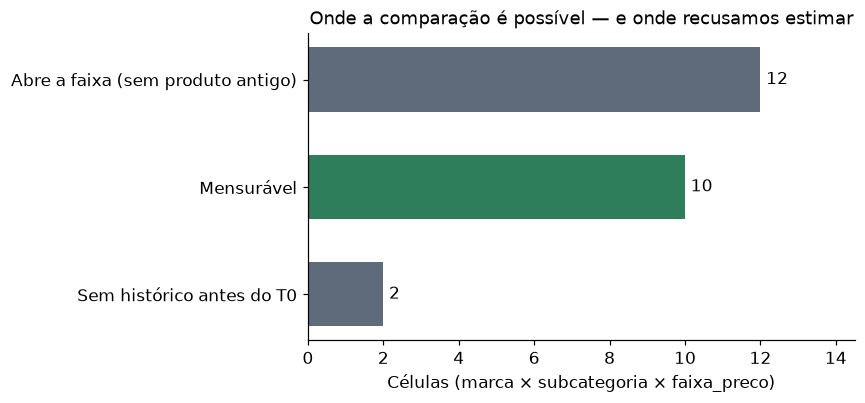

células mensuráveis: 10 de 24
projetos com ganho estimável: 10 de 25

Efeito (R$) é o ATT. A estatística do placebo é outra: RMSPE do pós ÷ RMSPE do pré.
p = fração de células sem lançamento com razão ≥ a da célula que lançou.


,cell_id,efeito_base_antiga_R$,rmspe_ratio_real,mediana_placebos,p_placebo,n_placebos
16,Eudora|Shampoo|P5,"114,976.30",1.53,1.33,0.46,35
19,O Boticário|Máscara|P1,432.05,1.18,1.99,0.77,35



**Como ler o histograma.** Cada barra é a fatia das 35 células *sem* lançamento naquele intervalo da razão. As alturas somam 100%. Linha cinza = mediana dessa nuvem. Linha colorida = a célula que lançou. O **p** da tabela é a massa à direita da linha colorida.

**Leitura dos dois exemplos.** O Shampoo (razão 1,53) sai um pouco acima da mediana das células sem projeto (1,33), mas 46% delas têm razão igual ou maior — o mesmo tamanho de desvio aparece no calendário, não é evidência de lançamento.

A Máscara (1,18) fica abaixo da mediana (1,99): depois do T0 o incumbente **não se afastou do espelho mais do que já se afastava no pré**, e esse afastamento é menor do que o típico das células sem projeto. O +R$ 432 é o saldo dessa cola que se manteve, não efeito do lançamento.


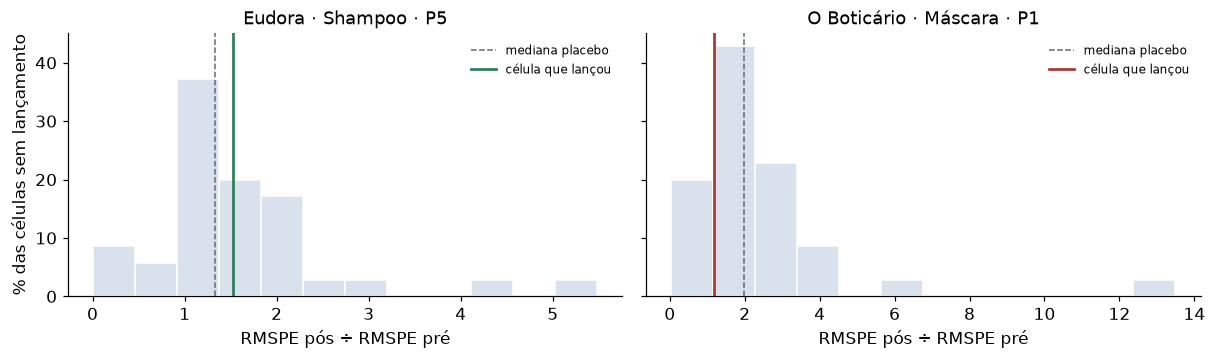

In [8]:
gmv_att = att.loc[att["metric"] == "gmv"].copy()
status_map = {
    "ok": "Mensurável",
    "sem_incumbente": "Abre a faixa (sem produto antigo)",
    "sem_pre_periodo_suficiente": "Sem histórico antes do T0",
    "ajuste_pre_fraco": "Espelho não colou no pré",
    "sem_doador": "Sem tríade para comparar",
    "sem_escala_pre": "Base antiga sem venda no pré",
    "incumbente_fora_antes_do_t0": "Incumbente já tinha saído de linha",
}
gmv_att["leitura"] = gmv_att["status"].map(status_map).fillna(gmv_att["status"])
contagem = gmv_att["leitura"].value_counts()

fig, ax = plt.subplots(figsize=(8.0, 3.8))
cores_st = [C["verde"] if i == "Mensurável" else C["cinza"] for i in contagem.index]
ax.barh(contagem.index[::-1], contagem.values[::-1], color=cores_st[::-1], height=0.6)
ax.set_xlabel("Células (marca × subcategoria × faixa_preco)")
ax.set_title("Onde a comparação é possível — e onde recusamos estimar")
for y, v in enumerate(contagem.values[::-1]):
    ax.text(v + 0.15, y, str(int(v)), va="center")
ax.set_xlim(0, contagem.max() + 2.5)
plt.tight_layout()
plt.show()

print("células mensuráveis:", int((gmv_att.status == "ok").sum()), "de", len(gmv_att))
print("projetos com ganho estimável:", int(roi["mb_incremental"].notna().sum()), "de", len(roi))
print()
print("Efeito (R$) é o ATT. A estatística do placebo é outra: RMSPE do pós ÷ RMSPE do pré.")
print("p = fração de células sem lançamento com razão ≥ a da célula que lançou.")
ids = ["Eudora|Shampoo|P5", "O Boticário|Máscara|P1"]
ex = gmv_att.loc[gmv_att.cell_id.isin(ids)].copy()
if "placebo_ratio_mediana" not in ex.columns and "placebo_ratios" in ex.columns:
    ex["placebo_ratio_mediana"] = ex["placebo_ratios"].map(
        lambda xs: float(np.median(xs)) if isinstance(xs, (list, tuple)) and len(xs) else np.nan
    )
keep = ["cell_id", "att_soma_pos", "rmspe_ratio"]
rename = {
    "att_soma_pos": "efeito_base_antiga_R$",
    "rmspe_ratio": "rmspe_ratio_real",
}
if "placebo_ratio_mediana" in ex.columns:
    keep.append("placebo_ratio_mediana")
    rename["placebo_ratio_mediana"] = "mediana_placebos"
if "placebo_pvalue_rmspe_ratio" in ex.columns:
    keep.append("placebo_pvalue_rmspe_ratio")
    rename["placebo_pvalue_rmspe_ratio"] = "p_placebo"
if "n_placebos" in ex.columns:
    keep.append("n_placebos")
ex = ex[keep].rename(columns=rename)
if "n_placebos" in ex.columns:
    ex["n_placebos"] = ex["n_placebos"].astype("Int64")
display(ex)

from IPython.display import Markdown
display(Markdown("""
**Como ler o histograma.** Cada barra é a fatia das 35 células *sem* lançamento naquele intervalo da razão. As alturas somam 100%. Linha cinza = mediana dessa nuvem. Linha colorida = a célula que lançou. O **p** da tabela é a massa à direita da linha colorida.

**Leitura dos dois exemplos.** O Shampoo (razão 1,53) sai um pouco acima da mediana das células sem projeto (1,33), mas 46% delas têm razão igual ou maior — o mesmo tamanho de desvio aparece no calendário, não é evidência de lançamento.

A Máscara (1,18) fica abaixo da mediana (1,99): depois do T0 o incumbente **não se afastou do espelho mais do que já se afastava no pré**, e esse afastamento é menor do que o típico das células sem projeto. O +R$ 432 é o saldo dessa cola que se manteve, não efeito do lançamento.
"""))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.4), sharey=True)
cores_ex = {"Eudora|Shampoo|P5": C["verde"], "O Boticário|Máscara|P1": C["vermelho"]}
for ax, cell_id in zip(axes, cores_ex):
    row = gmv_att.loc[gmv_att["cell_id"] == cell_id].iloc[0]
    ratios = row["placebo_ratios"] if "placebo_ratios" in gmv_att.columns else None
    if not isinstance(ratios, (list, tuple)):
        ratios = []
    if ratios:
        # cada célula sem lançamento pesa 100/n %; as alturas somam 100%
        w = np.full(len(ratios), 100.0 / len(ratios))
        ax.hist(ratios, bins=12, color=C["claro"], edgecolor="white", weights=w)
        ax.axvline(float(np.median(ratios)), color=C["cinza"], ls="--", lw=1.0, label="mediana placebo")
    ax.axvline(float(row["rmspe_ratio"]), color=cores_ex[cell_id], lw=1.8, label="célula que lançou")
    ax.set_title(cell_id.replace("|", " · "))
    ax.set_xlabel("RMSPE pós ÷ RMSPE pré")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("% das células sem lançamento")
plt.tight_layout()
plt.show()


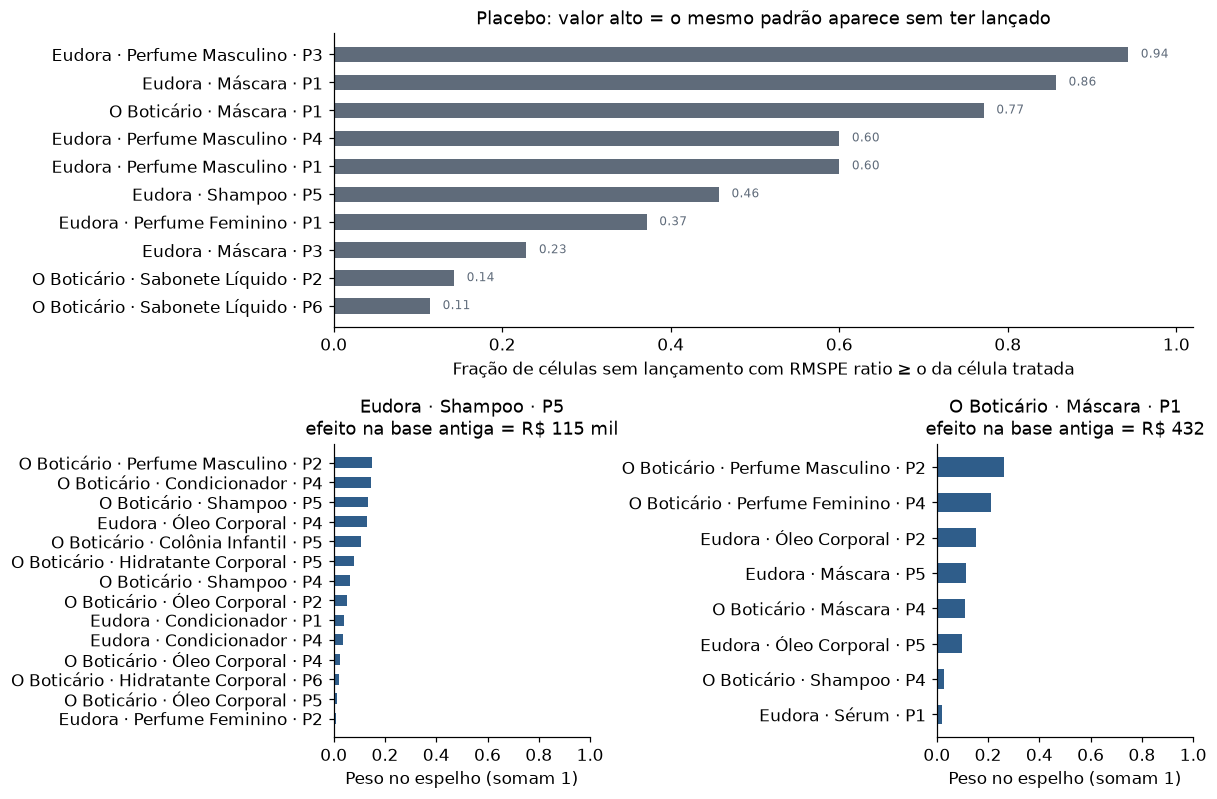

In [9]:
ok = att.loc[(att["metric"] == "gmv") & (att["status"] == "ok")].copy()
ok["rotulo"] = ok["marca_std"] + " · " + ok["subcategoria"] + " · " + ok["faixa_preco"]

fig = plt.figure(figsize=(11.2, 7.4))
ax_p = fig.add_subplot(2, 1, 1)
ord_p = ok.sort_values("placebo_pvalue_rmspe_ratio")
ax_p.barh(ord_p["rotulo"], ord_p["placebo_pvalue_rmspe_ratio"], color=C["cinza"], height=0.55)
ax_p.set_xlabel("Fração de células sem lançamento com RMSPE ratio ≥ o da célula tratada")
ax_p.set_title("Placebo: valor alto = o mesmo padrão aparece sem ter lançado")
ax_p.set_xlim(0, 1.02)
for y, v in enumerate(ord_p["placebo_pvalue_rmspe_ratio"]):
    ax_p.text(v + 0.015, y, f"{v:.2f}", va="center", fontsize=8, color=C["cinza"])

exemplos_peso = ["Eudora|Shampoo|P5", "O Boticário|Máscara|P1"]
for i, cell_id in enumerate(exemplos_peso):
    ax = fig.add_subplot(2, 2, 3 + i)
    row = ok.loc[ok["cell_id"] == cell_id].iloc[0]
    pesos = row["pesos"]
    itens = sorted(pesos.items(), key=lambda kv: kv[1])
    ax.barh([k.replace("|", " · ") for k, _ in itens], [v for _, v in itens], color=C["azul"], height=0.55)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Peso no espelho (somam 1)")
    att_rs = row["att_soma_pos"]
    ax.set_title(f"{cell_id.replace('|', ' · ')}\nefeito na base antiga = {brl(att_rs)}")
plt.tight_layout()
plt.show()

---

# 2. Formulação do ROI

## 2.1 A equação

O retorno é a margem que o Grupo ganhou de verdade, menos o que custou inovar. Os dois pedaços de margem — SKU novo e base antiga — somam **os mesmos ciclos**. Esse conjunto é `W`. A mídia **não** entra no `Σ`: é um único burst.

```
W = min(17, vida do incumbente depois do T0, último ciclo da amostra)

ROI = (
          Σ_{c ∈ W}  margem_bruta do SKU novo no ciclo c
        + Σ_{c ∈ W} (margem dos incumbentes − margem do espelho)_c
        − mídia de lançamento
      ) / mídia de lançamento
```

Primeira soma = sell-out do lançamento **em W** (coluna `mb`). Segunda soma = ATT **em W** (coluna `att_soma_roi`). Sem o `c ∈ W` nos dois, a conta mistura relógios.

Os 17 ciclos são o ano 1 deste calendário. A meta (`expectativa_gmv_ano1`) é ano 1; `investimento_mkt_rs` é verba para *nascer* o produto, não mídia de 25 ou 43 ciclos.

O que cada teto faz:

| Teto de W | Se ignorar |
|---|---|
| 17 ciclos | Soma a vida do SKU contra mídia de abertura |
| Vida do incumbente depois do T0 | Depois do `phase_out` não há contrafactual vivo. O que o novo vende no lugar do SKU deslistado entra como ganho |
| Fim da amostra | Trata lançamento recente como ano 1 completo |

Não rateamos a mídia quando `W < 17` e não anualizamos `W` curto. Selo **Paga a mídia** só com `W = 17`. Senão: **Ano 1 incompleto**.

O ATT só entra se a célula for mensurável; senão o ROI fica em branco. Event study e placebo seguem até o phase-out (`att_soma_pos`); só o ROI corta em `W`.

**Dois cortes, dois projetos.** Máscara: o incumbente (`SKU_014`) sai em `202507`, então `W = 6` e o selo é incompleto. Perfume Masculino Eudora P1 (`SKU_120`): o incumbente segue na gôndola 36 ciclos depois do T0; `W` para no **17** porque é ano 1. Aí o selo pode ser “Paga / Não paga”.

| Peça | Máscara Boticário P1 (`SKU_092`) | Perfume Masculino Eudora P1 (`SKU_120`) |
|---|---|---|
| O que prende W | Incumbente sai | Ano 1 |
| W | 6 ciclos | **17 ciclos** |
| Lançamento na gôndola | 25 ciclos | 36 ciclos |
| MB do novo em W | R$ 21,4 mil | R$ 74,9 mil |
| Δ MB da base em W | +R$ 258 | +R$ 253 |
| MB incremental em W | R$ 21,7 mil | R$ 75,2 mil |
| Mídia | R$ 500 mil | R$ 250 mil |
| ROI | −0,96 | −0,70 |
| Selo | Ano 1 incompleto | Não paga a mídia |

Na Máscara, sem o corte a conta somaria 25 ciclos do novo + 6 de ATT — os 19 depois da deslistagem entrariam como ganho. No perfume, a margem na vida (36 ciclos, R$ 145 mil) **não entra**; o ATT dos 36 ciclos do incumbente até muda de sinal (−R$ 6,2 mil de margem). O ROI usa só os 17 (+R$ 253).

O Custo que propomos é a soma abaixo. Nesta planilha só observamos a mídia de lançamento. O restante entra como parâmetro — default 0 = “não informado”, não “custo típico”.

| Termo | O que é | Na planilha? | Na equação |
|---|---|---|---|
| Margem do SKU novo em W | Margem bruta observada do lançamento nos ciclos de W. Já desconta o CMV típico daquele SKU. | Sim — `margem_bruta` em `tb_vendas` | Primeira soma |
| Efeito na base antiga em W | O que a margem dos incumbentes fez versus o espelho, nos **mesmos** ciclos. Negativo = canibalização; positivo = a faixa foi puxada. | Só se a célula for mensurável | Segunda soma (ou fica em branco) |
| Mídia de lançamento | Verba para *nascer* o produto. Um número, não um `Σ` em W. | Sim — `investimento_mkt_rs` | Subtrai no numerador; divide |
| P&D, registro, prototipagem | Desenvolver fórmula, testes, registro sanitário, embalagem. Gasto *antes* da gôndola. | **Não** | `c_pd`, default 0 |
| Transição de estoque (write-off) | Perda com o que sobra na troca de linha: incumbente que sai e não vende, ou lançamento que encalha. | **Não** | `c_estoque`, default 0 |
| Mídia de sustentação | Verba *depois* do burst de lançamento para manter o SKU vivo. Se `investimento_mkt_rs` for só a abertura, esta peça falta. | **Não** | `c_sustentacao`, default 0 |
| Custo fabril/logístico extra | Custo de fábrica e cadeia que a `margem_bruta` não captura: setup de linha, SKU a mais no CD, frete da novidade. O CMV do antigo que deixou de vender já entra no ATT. | **Não** | Time de negócio preenche; sem coluna, não imputamos |
| Imposto além de `margem_bruta_pct` | Se a margem da base não for líquida de todos os tributos, falta o residual. Sem dicionário do campo, não inventamos. | **Não** | Fora |

Dois números:

```
ROI_parcial (só mídia) = (MB_incremental_em_W − mídia) / mídia     ← o que esta base permite

ROI_completo           = (MB_incremental_em_W − Custo_total) / Custo_total
                       Custo_total = mídia + P&D + transição de estoque + sustentação
                       (+ fabril extra, quando o time informar)
```

Nesta entrega o ROI completo **coincide** com o parcial porque os custos faltantes entram como zero *explícito* (“não informado”). Quando o funcional preencher P&D e estoque, o `ROI_full` deixa de ser igual ao parcial.

Código: `src/incrementality/roi.py`. `W` no código é `n_post_roi`.


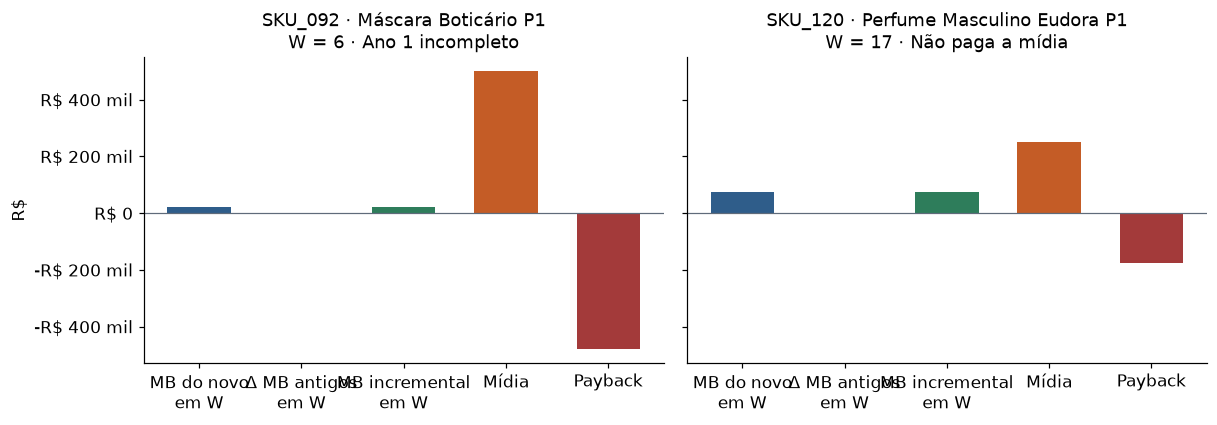

,peça,Máscara Boticário P1,Perfume Masculino Eudora P1
0,O que prende W,incumbente sai,ano 1
1,W (ciclos na equação),6,17
2,Lançamento na gôndola,25,36
3,Margem do lançamento em W,"21,423.78","74,904.37"
4,+ Δ margem dos antigos em W,258.21,253.10
5,= MB incremental em W,"21,681.99","75,157.47"
6,− mídia (não rateada),"-500,000.00","-250,000.00"
7,= payback,"-478,318.01","-174,842.53"
8,ROI parcial,-0.96,-0.70
9,Margem na vida do SKU — fora da equação,"87,510.50","145,350.02"


In [10]:
# Dois cortes: incumbente sai (Máscara, W=6) vs ano 1 completo (Perfume P1, W=17).
skus = ["SKU_092", "SKU_120"]
exs = [roi.loc[roi["cod_sku_lancamento"] == s].iloc[0] for s in skus]
titulos = ["Máscara Boticário P1", "Perfume Masculino Eudora P1"]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), sharey=True)
passos = ["MB do novo\nem W", "Δ MB antigos\nem W", "MB incremental\nem W", "Mídia", "Payback"]
for ax, ex, titulo in zip(axes, exs, titulos):
    w = int(ex["n_post_roi"])
    vals = [ex["mb"], ex["mb_spillover_alocado"], ex["mb_incremental"], ex["investimento_mkt_rs"], ex["payback_parcial_midia"]]
    cores_w = [C["azul"], C["vermelho"] if vals[1] < 0 else C["verde"], C["verde"], C["laranja"], C["vermelho"] if vals[4] < 0 else C["verde"]]
    ax.bar(passos, vals, color=cores_w, width=0.62)
    ax.axhline(0, color=C["cinza"], lw=0.8)
    ax.set_title(f"{ex['cod_sku_lancamento']} · {titulo}\nW = {w} · {ex['selo']}")
    ax.yaxis.set_major_formatter(FuncFormatter(brl))
axes[0].set_ylabel("R$")
plt.tight_layout()
plt.show()

pecas = pd.DataFrame({
    "peça": [
        "O que prende W",
        "W (ciclos na equação)",
        "Lançamento na gôndola",
        "Margem do lançamento em W",
        "+ Δ margem dos antigos em W",
        "= MB incremental em W",
        "− mídia (não rateada)",
        "= payback",
        "ROI parcial",
        "Margem na vida do SKU — fora da equação",
        "Selo",
    ],
})
for ex, titulo in zip(exs, titulos):
    pecas[titulo] = [
        "incumbente sai" if int(ex["n_post_roi"]) < 17 else "ano 1",
        int(ex["n_post_roi"]),
        int(ex["ciclos_expostos"]),
        ex["mb"],
        ex["mb_spillover_alocado"],
        ex["mb_incremental"],
        -ex["investimento_mkt_rs"],
        ex["payback_parcial_midia"],
        ex["roi_parcial_midia"],
        ex["mb_vida"],
        ex["selo"],
    ]
pecas


## 2.2 Por que o selo olha margem, não GMV

Faturamento extra pode ser positivo e a margem extra negativa (o mix piorou: vendeu mais barato / menos rentável). Retorno diz se o investimento se paga.

O selo é carimbo no **SKU novo**, não no incumbente. Dois relógios:

- `ciclos_expostos` — quanto o lançamento está na gôndola. Corte de **6 ciclos** (`MIN_CYCLES_FOR_SELO`): não carimbar payback com dois ou três ciclos de sell-out.
- `n_post_roi` — tamanho de `W`. Se `< 17`, **Ano 1 incompleto** (incumbente saiu ou a amostra acaba). Não é o `n_post` do gráfico: aquele vai até o phase-out.

Nesta base nenhum projeto cai em “Cedo demais” (o mais novo tem 9 ciclos). A Máscara Boticário P1 (`SKU_092`) tem **25** ciclos de exposição; o ROI usa **6** (vida do incumbente `SKU_014`). O sabonete Boticário P6 (`SKU_089`) fica acima da diagonal em R$, mas com `W = 9` — selo incompleto, não “Paga a mídia”.

Regras, nesta ordem:

| Selo | Quando |
|---|---|
| **Cedo demais** | Lançamento com menos de 6 ciclos na gôndola |
| **Não dá para medir** | Sem produto antigo na faixa / sem histórico antes / espelho não colou / SKU nasceu depois da janela da célula |
| **Ano 1 incompleto** | Δ estimável, mas `W < 17` |
| **Paga a mídia** | Janela completa, MB incremental > 0 e maior que a mídia |
| **Não paga a mídia** | Janela completa, MB incremental > 0, menor que a mídia |
| **Piorou o mix** | GMV incremental > 0 e MB incremental ≤ 0 |
| **Comeu a base** | GMV incremental ≤ 0 |

Não anualizamos `W` curto × 17 como se fosse ano 1.

**O que de propósito não entra na conta:** imputar P&D “típico de cosmético”; extrapolar Brasil a partir de SP/PR; usar `tb_skus_similares` como mapa de canibalização; misturar P1 com P6 no mesmo contrafactual.


---

# 3. Aplicação prática e tomada de decisão

Trocar a pergunta **“bateu a meta de GMV?”** por **“gerou margem a mais que pague o investimento?”**.


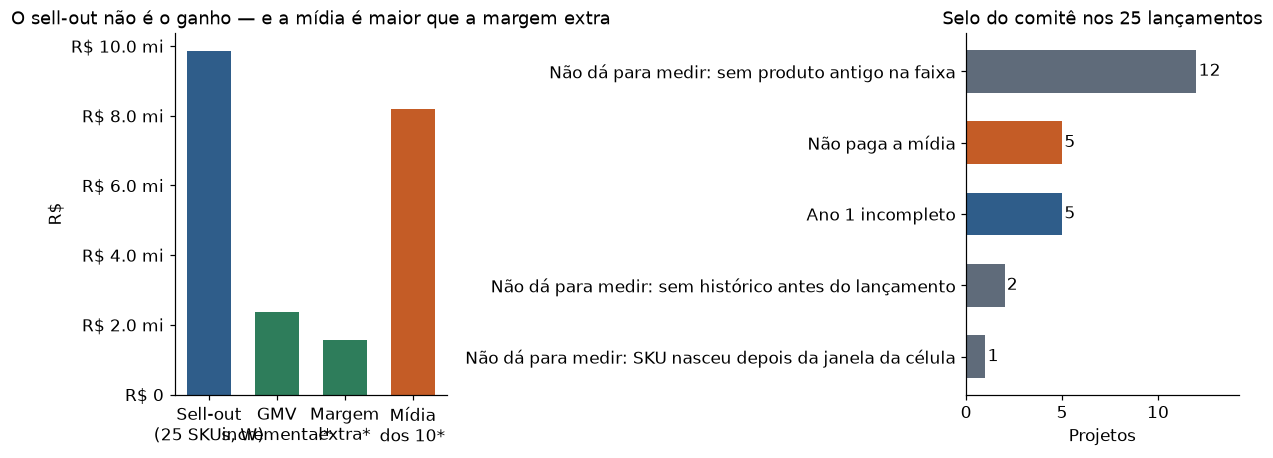

GMV dos 25 lançamentos (janela W)          9,868,637.00
Projetos em que dá para estimar o ganho           10.00
GMV incremental (10 projetos)              2,356,716.64
Margem extra (10 projetos)                 1,570,202.96
Mídia desses 10                            8,200,000.00
Mídia − margem extra                      -6,629,797.04

Leitura: o drama não é canibalização generalizada. É mídia alta na frente de margem extra pequena.
* incremental e mídia referem-se aos 10 projetos mensuráveis. Sell-out dos 25 já está na janela W (até 17 ciclos).


In [11]:
estim = roi.loc[roi["mb_incremental"].notna()]
n_est = int(len(estim))
kpis = pd.Series({
    "GMV dos 25 lançamentos (janela W)": float(roi["gmv"].sum()),
    "Projetos em que dá para estimar o ganho": n_est,
    f"GMV incremental ({n_est} projetos)": float(roi["gmv_incremental"].sum(skipna=True)),
    f"Margem extra ({n_est} projetos)": float(roi["mb_incremental"].sum(skipna=True)),
    f"Mídia desses {n_est}": float(estim["investimento_mkt_rs"].sum()),
    "Mídia − margem extra": float(estim["payback_parcial_midia"].sum()),
})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.3))

lab = ["Sell-out\n(25 SKUs, W)", "GMV\nincremental*", "Margem\nextra*", f"Mídia\ndos {n_est}*"]
val = [roi["gmv"].sum(), roi["gmv_incremental"].sum(skipna=True), roi["mb_incremental"].sum(skipna=True), estim["investimento_mkt_rs"].sum()]
axes[0].bar(lab, val, color=[C["azul"], C["verde"], C["verde"], C["laranja"]], width=0.65)
axes[0].set_ylabel("R$")
axes[0].set_title("O sell-out não é o ganho — e a mídia é maior que a margem extra")
axes[0].yaxis.set_major_formatter(FuncFormatter(brl))

selo = roi["selo"].value_counts()
cores_selo = []
for s in selo.index:
    if s == "Paga a mídia":
        cores_selo.append(C["verde"])
    elif s == "Não paga a mídia":
        cores_selo.append(C["laranja"])
    elif s == "Ano 1 incompleto":
        cores_selo.append(C["azul"])
    else:
        cores_selo.append(C["cinza"])
axes[1].barh(selo.index[::-1], selo.values[::-1], color=list(reversed(cores_selo)), height=0.6)
axes[1].set_xlabel("Projetos")
axes[1].set_title("Selo do comitê nos 25 lançamentos")
for y, v in enumerate(selo.values[::-1]):
    axes[1].text(v + 0.12, y, str(int(v)), va="center")
axes[1].set_xlim(0, selo.max() + 2.2)
plt.tight_layout()
plt.show()

print(kpis.to_string())
print()
print("Leitura: o drama não é canibalização generalizada. É mídia alta na frente de margem extra pequena.")
print(f"* incremental e mídia referem-se aos {n_est} projetos mensuráveis. Sell-out dos 25 já está na janela W (até 17 ciclos).")


In [12]:
# Painel de decisão: ROI + diagnóstico do espelho (src/incrementality/roi.py)
from incrementality.roi import build_painel_comite

painel = build_painel_comite(roi, att).sort_values(["selo", "gmv"], ascending=[True, False]).copy()
for col in ("gmv", "mb", "gmv_spillover_alocado", "mb_spillover_alocado", "gmv_incremental", "mb_incremental", "investimento_mkt_rs", "payback_parcial_midia"):
    if col in painel.columns:
        painel[col] = painel[col].round(0)
for col in ("fit_rel_pre_gmv", "fit_rel_pre_mb", "placebo_pvalue_gmv", "placebo_pvalue_mb", "roi_parcial_midia"):
    if col in painel.columns:
        painel[col] = painel[col].round(3)
painel


,id_projeto,cod_sku_lancamento,marca_std,subcategoria,faixa_preco,n_projetos_celula,att_status,n_post_roi,ciclos_expostos,janela_roi_incompleta,fit_rel_pre_gmv,fit_rel_pre_mb,...,placebo_pvalue_mb,gmv,mb,gmv_spillover_alocado,mb_spillover_alocado,gmv_incremental,mb_incremental,investimento_mkt_rs,payback_parcial_midia,roi_parcial_midia,alerta_pouco_tempo,selo
19,PROJ_2025_08,SKU_039,Eudora,Shampoo,P5,1,ok,16,16,True,0.07,0.06,...,0.46,"573,326.00","407,063.00","114,976.00","71,728.00","688,302.00","478,791.00","2,000,000.00","-1,521,209.00",-0.76,True,Ano 1 incompleto
13,PROJ_2025_02,SKU_089,O Boticário,Sabonete Líquido,P6,1,ok,9,9,True,0.09,0.09,...,0.11,"389,474.00","288,212.00","24,284.00","14,930.00","413,758.00","303,142.00","250,000.00","53,142.00",0.21,True,Ano 1 incompleto
20,PROJ_2025_09,SKU_118,Eudora,Perfume Masculino,P4,1,ok,11,16,True,0.10,0.10,...,0.57,"283,037.00","164,162.00","-1,357.00",-704.00,"281,680.00","163,458.00","2,000,000.00","-1,836,542.00",-0.92,True,Ano 1 incompleto
7,PROJ_2024_08,SKU_070,Eudora,Máscara,P3,1,ok,15,12,True,0.09,0.09,...,0.26,"220,087.00","110,042.00","25,114.00","12,237.00","245,202.00","122,279.00","750,000.00","-627,721.00",-0.84,True,Ano 1 incompleto
17,PROJ_2025_06,SKU_092,O Boticário,Máscara,P1,1,ok,6,25,True,0.07,0.07,...,0.77,"37,584.00","21,424.00",432.00,258.00,"38,017.00","21,682.00","500,000.00","-478,318.00",-0.96,True,Ano 1 incompleto
22,PROJ_2025_11,SKU_053,Eudora,Perfume Masculino,P3,2,fora_da_janela_da_celula,17,9,False,0.26,0.18,...,0.91,0.00,0.00,NaN,NaN,NaN,NaN,"1,200,000.00",NaN,NaN,True,Não dá para medir: SKU nasceu depois da janela...
8,PROJ_2024_09,SKU_085,Eudora,Shampoo,P6,1,sem_pre_periodo_suficiente,17,43,False,NaN,NaN,...,NaN,"1,400,936.00","1,022,681.00",NaN,NaN,NaN,NaN,"750,000.00",NaN,NaN,False,Não dá para medir: sem histórico antes do lanç...
23,PROJ_2025_12,SKU_119,O Boticário,Perfume Feminino,P6,1,sem_pre_periodo_suficiente,17,40,False,NaN,NaN,...,NaN,"1,067,735.00","640,639.00",NaN,NaN,NaN,NaN,"750,000.00",NaN,NaN,False,Não dá para medir: sem histórico antes do lanç...
3,PROJ_2024_04,SKU_114,Eudora,Perfume Masculino,P6,1,sem_incumbente,16,13,True,NaN,NaN,...,NaN,"949,913.00","560,447.00",NaN,NaN,NaN,NaN,"750,000.00",NaN,NaN,True,Não dá para medir: sem produto antigo na faixa
24,PROJ_2025_13,SKU_112,Eudora,Sérum,P6,1,sem_incumbente,17,20,False,NaN,NaN,...,NaN,"855,784.00","513,472.00",NaN,NaN,NaN,NaN,"750,000.00",NaN,NaN,False,Não dá para medir: sem produto antigo na faixa


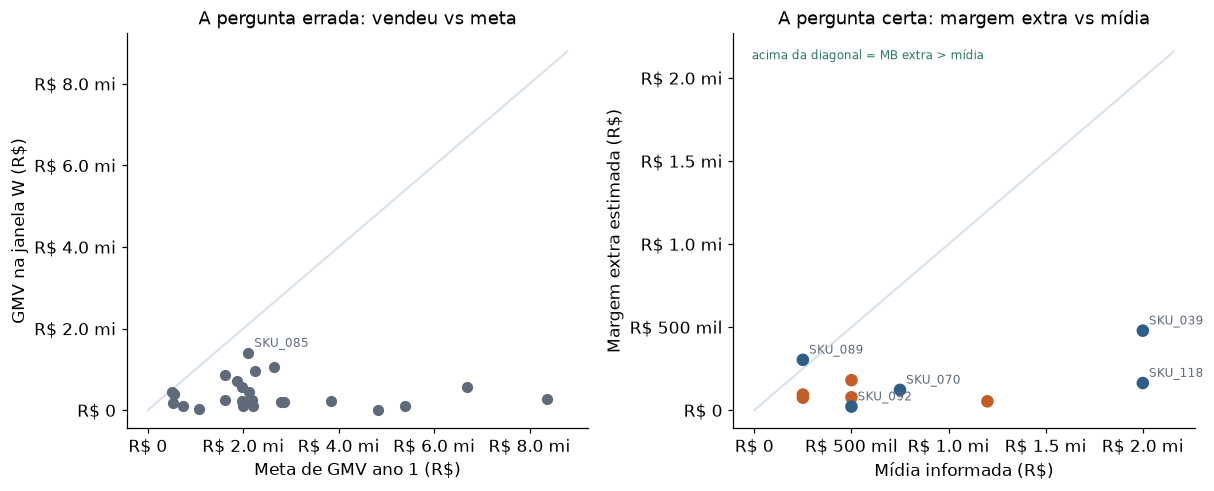

Acima da diagonal:   id_projeto cod_sku_lancamento  n_post_roi  roi_parcial_midia             selo
PROJ_2025_02            SKU_089           9               0.21 Ano 1 incompleto
Nenhum com W = 17 completa paga a mídia.
SKU_085 e SKU_119 (maiores sell-outs) não aparecem à direita: sem histórico antes do lançamento.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

# esquerda: GMV bruto vs meta — a pergunta errada
axes[0].scatter(roi["expectativa_gmv_ano1"], roi["gmv"], c=C["cinza"], s=40, zorder=3)
lo = 0
hi = max(roi["expectativa_gmv_ano1"].max(), roi["gmv"].max()) * 1.05
axes[0].plot([lo, hi], [lo, hi], color=C["claro"], lw=1.4)
for _, r in roi.loc[roi["gmv"] > 1.4e6].iterrows():
    axes[0].annotate(r["cod_sku_lancamento"], (r["expectativa_gmv_ano1"], r["gmv"]),
                     textcoords="offset points", xytext=(4, 4), fontsize=8, color=C["cinza"])
axes[0].set_xlabel("Meta de GMV ano 1 (R$)")
axes[0].set_ylabel("GMV na janela W (R$)")
axes[0].set_title("A pergunta errada: vendeu vs meta")
axes[0].xaxis.set_major_formatter(FuncFormatter(brl))
axes[0].yaxis.set_major_formatter(FuncFormatter(brl))

# direita: margem extra vs mídia — a pergunta certa (só mensuráveis)
m = estim.copy()
cor = np.where(m["selo"] == "Paga a mídia", C["verde"],
               np.where(m["selo"] == "Ano 1 incompleto", C["azul"], C["laranja"]))
axes[1].scatter(m["investimento_mkt_rs"], m["mb_incremental"], c=cor, s=52, zorder=3)
mx = max(m["investimento_mkt_rs"].max(), m["mb_incremental"].max()) * 1.08
axes[1].plot([0, mx], [0, mx], color=C["claro"], lw=1.4)
axes[1].set_xlabel("Mídia informada (R$)")
axes[1].set_ylabel("Margem extra estimada (R$)")
axes[1].set_title("A pergunta certa: margem extra vs mídia")
axes[1].xaxis.set_major_formatter(FuncFormatter(brl))
axes[1].yaxis.set_major_formatter(FuncFormatter(brl))
acima = m["mb_incremental"] > m["investimento_mkt_rs"]
for _, r in m.iterrows():
    if r["selo"] == "Paga a mídia" or r["selo"] == "Ano 1 incompleto" or r["investimento_mkt_rs"] >= 1.5e6:
        axes[1].annotate(r["cod_sku_lancamento"], (r["investimento_mkt_rs"], r["mb_incremental"]),
                         textcoords="offset points", xytext=(4, 4), fontsize=8, color=C["cinza"])
axes[1].text(0.04, 0.96, "acima da diagonal = MB extra > mídia", transform=axes[1].transAxes,
             va="top", fontsize=8, color=C["verde"])
plt.tight_layout()
plt.show()

print("Acima da diagonal:", m.loc[acima, ["id_projeto", "cod_sku_lancamento", "n_post_roi", "roi_parcial_midia", "selo"]].to_string(index=False))
print("Nenhum com W = 17 completa paga a mídia.")
print("SKU_085 e SKU_119 (maiores sell-outs) não aparecem à direita: sem histórico antes do lançamento.")


## 3.1 O que os números desta base dizem

Recorte: `marca` × `subcategoria` × `faixa_preco`. SP e PR. Sell-out e ATT do ROI na janela `W` (até 17 ciclos, ou menos se o incumbente sair / a amostra acabar).

- Os 25 lançamentos faturaram ~ **R$ 9,87 milhões** nessa janela. Esse ainda é o número que costuma ir para o slide de “sucesso” — agora alinhado à meta de ano 1, não à vida inteira do SKU.
- Desses, dá para estimar o ganho de verdade em **10** projetos. Nos outros **15** o selo diz o motivo: sem produto antigo na faixa (12), sem histórico antes do lançamento (2) ou o SKU nasceu depois da janela da célula (1 — segundo perfume Eudora P3).
- Ganho de faturamento nesses 10: ~ **R$ 2,36 milhões**. Grande parte da venda bruta **não** é ganho de portfólio — ou não dá para cravar.
- Margem extra nesses 10: ~ **R$ 1,57 milhão**. Mídia desses 10: **R$ 8,2 milhões**. Payback parcial: ~ **− R$ 6,63 milhões**.
- Classificação: **0** paga a mídia com `W` completo, **5** geram margem extra e não pagam, **5** ainda estão em ano 1 incompleto. `SKU_089` (sabonete Boticário P6) fica acima da diagonal em R$, mas com 9 ciclos — incompleto, não carimbo de payback.

**Leitura honesta.** Não há, nesta conta, um caso claro de “o lançamento destruiu a célula inteira”. O problema dominante **não** é canibalização generalizada. É **gasto de mídia alto** na frente de uma margem extra pequena. Mexer spend e preço muda mais o retorno do que só desligar o SKU.

**Os dois maiores sell-outs** (`SKU_085` shampoo Eudora P6 e `SKU_119` perfume feminino Boticário P6) nascem sem histórico *antes*. Celebrar GMV bruto aqui seria chute. `SKU_082` (condicionador Eudora P5) não entra na conta: não há produto antigo na faixa P5.


## 3.2 O que o comitê faz com cada selo

| Situação | O que fazer |
|---|---|
| Paga a mídia | Candidato a repetir / escalar. Só com `W` de 17 ciclos. |
| Ano 1 incompleto | Número ainda é provisório. Esperar o ano (ou o incumbente) completar. Não anualizar. |
| Margem extra positiva, mas não paga a mídia | Não é fracasso de produto automaticamente. Revisar **mídia e preço**, não só descontinuar o SKU. |
| Fatura, mas a margem extra é zero ou negativa | O mix piorou. Recusar ou reposicionar. |
| Comeu a base (GMV incremental ≤ 0) | Não escalar; rever se o produto novo era de fato outro mercado. |
| Não dá para medir (abre a faixa ou sem “antes”) | **Não matar** por falta de prova — e **não celebrar** sell-out como ganho. |
| Cedo demais (< 6 ciclos) | Esperar. Não anualizar a venda de poucos ciclos como se fosse ano cheio. |

## 3.3 Checkpoints do comitê

A seção 3.2 diz **como interpretar** cada selo. Aqui está **quando** revisar: seis checkpoints no ciclo do lançamento — listas mínimas antes de avançar. Não são métricas novas; são governança para não usar o número errado na hora errada (detalhes no relatório metodológico em `docs/`, seção 15.3).

1. **Checkpoint 1 — conceito (antes de desenvolver).** Já existe produto antigo **naquela faixa**? Se o lançamento inaugura o degrau, o comitê sabe de antemão que o deslocamento não será mensurável. Se dois projetos caem na mesma célula, aprova-se um **pacote**, não dois SKUs como experimentos separados.
2. **Checkpoint 2 — investimento (antes de liberar verba).** Exigir o retorno **completo**, com P&D e estoque preenchidos. Sem isso, só sai o retorno com mídia, marcado incompleto.
3. **Checkpoint 3 — mensuração (antes de ir a mercado).** Reservar pelo menos 4 ciclos de história da base antiga **daquela faixa** antes do lançamento. Senão o produto nasce cego — caso do shampoo Eudora P6.
4. **Checkpoint 4 — acompanhamento (durante o primeiro ano).** Atualizar sell-out e margem; comparar observado vs sintético; não anualizar poucos ciclos; manter selo provisório se `W` incompleta.
5. **Checkpoint 5 — escala ou correção (com 17 ciclos em `W`).** Usar a tabela de selos. “Não paga a mídia” não é desligar o produto no automático; escalar só com economia e evidência coerentes.
6. **Checkpoint 6 — saída (quando incumbente ou lançamento sair de linha).** Parar a conta no último ciclo válido; incluir custo de estoque do encerramento; não ler zero pós-saída como canibalização.

## 3.4 O que esta base não deixa dizer

- Não é Brasil: só **SP e PR**.
- Não temos custo de P&D, write-off de estoque, mídia de sustentação, imposto além da margem do cadastro.
- Os 59 produtos novos fora da tabela oficial foram **tirados** da comparação de propósito. Se o negócio quiser “toda inovação”, precisa da lista completa — esta tabela de 25 não é isso.
- “Parece que expandiu” numa célula nem sempre passa no placebo. Não vender movimento positivo como expansão comprovada se o mesmo padrão aparece em células **sem** lançamento.


## Mini-glossário

| Palavra | Significado |
|---|---|
| Ciclo | `cod_ciclo` em `tb_vendas`. |
| Célula | `marca` × `subcategoria` × `faixa_preco` (ex.: Eudora × Perfume Masculino × P1). |
| Incumbente | Produto que já existia: `cod_ciclo_phase_in` < `202401` e fora dos 25 de `tb_projetos_lancamento`. Coluna `is_incumbent`. É a base antiga. |
| ATT | *Average Treatment Effect on the Treated.* Em português: **efeito na base antiga** da célula que lançou. Soma de (incumbentes observados − espelho). `att_soma_pos` = pós identificado (até o phase-out). `att_soma_roi` = a mesma soma na janela `W` do ROI. Não é o efeito no SKU novo. |
| W | Janela comum do ROI: `min(17, vida do incumbente depois do T0, fim da amostra)`. |
| Canibalização | Efeito na base antiga negativo: o novo come venda do incumbente da **mesma empresa**. |
| GMV incremental | Sell-out do lançamento em `W` + `att_soma_roi` em GMV. |
| MB incremental | Margem do lançamento em `W` + `att_soma_roi` em margem. |
| Espelho / sintético | Mistura de células **sem** projeto em `tb_projetos_lancamento`, pesos ≥ 0 somando 1. |
| RMSPE | *Root Mean Squared Prediction Error.* Raiz da média dos (incumbentes − espelho)². Erro típico por ciclo, em R$. O corte de 30% é RMSPE do pré ÷ média da série no pré. |
| Placebo | Mesmo T0 aplicado a células sem lançamento. Ratio alto também no controle → não vender como prova. |
| Selo | Veredito. Quando não dá para medir, o próprio nome diz o motivo. |

## Onde está o código

| Peça | Arquivo |
|---|---|
| Limpeza | `src/incrementality/prepare.py` |
| Controle sintético e efeito na base antiga | `src/incrementality/model.py` |
| ROI, selo e painel do comitê | `src/incrementality/roi.py` |
| Recalcular tabelas (CSV) | `scripts/run_pipeline.py` |
| Painel de decisão | `outputs/tables/painel_comite.csv` |
